# 01 — Preprocessing Pipeline Demo
This notebook walks through each stage of the BGT image preprocessing pipeline visually.

In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import skeletonize



In [22]:

# utils

def display_img(img):
  plt.imshow(img, cmap='gray')
  plt.axis("off")
  plt.show()

def upload_img(title, img):
    cv2.imwrite(title, img)

## Convet to grayscale

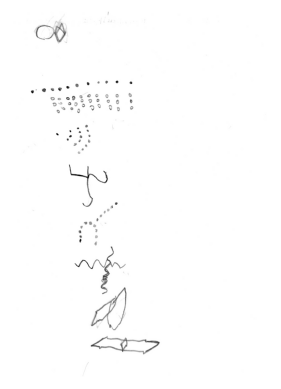

(1755, 1241, 3)


In [23]:
img = cv2.imread(r"F:\Github\bender-gestalt-analysis\data\rraw_drawings\page-0008.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

display_img(gray)
upload_img(r"F:\Github\bender-gestalt-analysis\notebooks\tests\gray.jpg",gray)
print(img.shape)



## Denoised (Noise Removal)

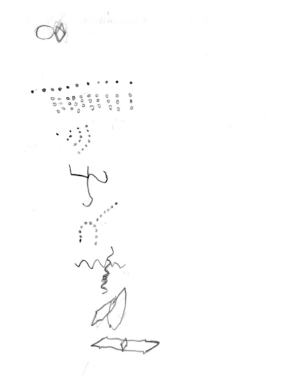

In [24]:
denoise = cv2.GaussianBlur(gray, (5, 5), 0)
display_img(denoise)
upload_img(r"tests\denoised.jpg",denoise)



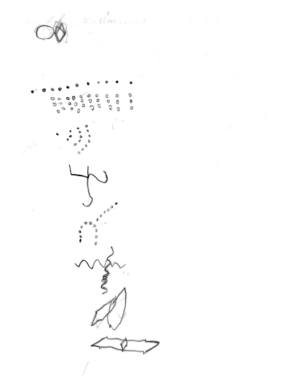

In [25]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(denoise)

display_img(enhanced)
upload_img(r"tests\enhanced.jpg",enhanced)



## Segmentation using Threshold

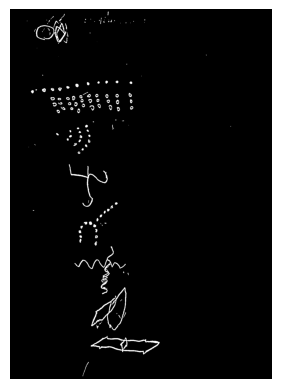

In [26]:
thresh = cv2.adaptiveThreshold(
    enhanced,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    10
)

display_img(thresh)
upload_img(r"tests\thresh.jpg",thresh)



more accurate after segmentation by threshold

## Morphological (using Erosion)

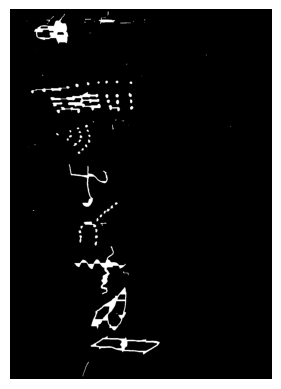

In [27]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

clean = cv2.morphologyEx(
    thresh,
    cv2.MORPH_CLOSE,
    kernel
)

# 1) Close gaps between neighboring dots
kernel_dots = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (25, 7)   # width > height to connect dots in a row
)

dots_connected = cv2.morphologyEx(
    clean,
    cv2.MORPH_CLOSE,
    kernel_dots,
    iterations=1
)

display_img(dots_connected)
# upload_img(r"tests\clean.jpg",clean)


## Skeletonizer

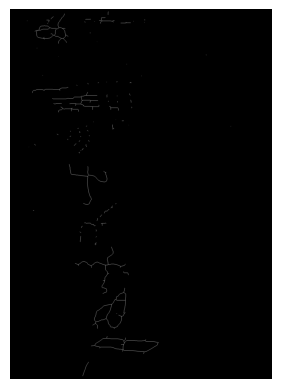

In [28]:
skeleton = skeletonize(dots_connected // 255)
skeleton = (skeleton * 255).astype("uint8")


display_img(skeleton)
# upload_img(r"tests\skeleton.jpg",skeleton)


## Find Contours

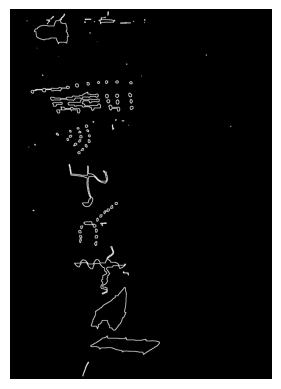

In [29]:
# find contours
contours, _ = cv2.findContours(
    dots_connected,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# create blank image
contour_img = np.zeros_like(clean)

# draw contours
cv2.drawContours(
    contour_img,
    contours,
    -1,
    255,
    2
)

display_img(contour_img)
upload_img(r"tests\contours.jpg",contour_img)


Area = 110.0
Perimeter = 158.3675308227539
Aspect Ratio = 0.4264705882352941
------------------------------
Area = 14689.5
Perimeter = 771.00208735466
Aspect Ratio = 3.6741573033707864
------------------------------
Area = 16756.0
Perimeter = 703.2691135406494
Aspect Ratio = 0.8235294117647058
------------------------------
Area = 60.0
Perimeter = 76.97056245803833
Aspect Ratio = 1.4444444444444444
------------------------------
Area = 6017.0
Perimeter = 1176.2295731306076
Aspect Ratio = 1.0704845814977975
------------------------------
Area = 143.0
Perimeter = 52.28427052497864
Aspect Ratio = 0.6190476190476191
------------------------------
Area = 225.5
Perimeter = 86.87005722522736
Aspect Ratio = 0.35294117647058826
------------------------------
Area = 131.0
Perimeter = 44.14213538169861
Aspect Ratio = 0.9285714285714286
------------------------------
Area = 118.5
Perimeter = 43.899494767189026
Aspect Ratio = 1.0
------------------------------
Area = 109.5
Perimeter = 43.5563489198

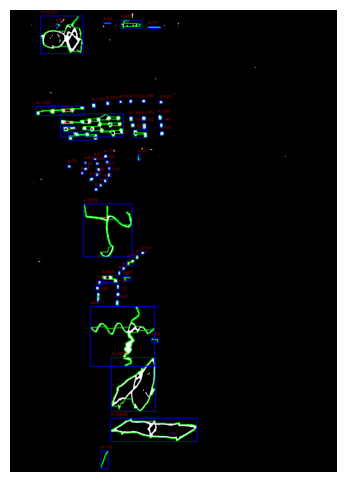

In [30]:
# copy image for drawing features
feature_img = cv2.cvtColor(clean, cv2.COLOR_GRAY2BGR)

for cnt in contours:

    # ignore tiny noise
    area = cv2.contourArea(cnt)

    if area < 50:
        continue

    # perimeter
    perimeter = cv2.arcLength(cnt, True)

    # bounding box
    x, y, w, h = cv2.boundingRect(cnt)

    # aspect ratio
    aspect_ratio = w / h

    # draw contour
    cv2.drawContours(feature_img, [cnt], -1, (0,255,0), 2)

    # draw rectangle
    cv2.rectangle(
        feature_img,
        (x, y),
        (x+w, y+h),
        (255,0,0),
        2
    )

    # print info on image
    cv2.putText(
        feature_img,
        f"A:{int(area)}",
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0,0,255),
        1
    )

    print("Area =", area)
    print("Perimeter =", perimeter)
    print("Aspect Ratio =", aspect_ratio)
    print("-"*30)

# show final image
plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(feature_img, cv2.COLOR_BGR2RGB))

plt.axis("off")
plt.show()

upload_img(r"tests\features.jpg",feature_img)




Rotation Angle = -67.12633514404297
Rotation Angle = -83.1572265625
Rotation Angle = -39.7187614440918
Rotation Angle = -65.55604553222656
Rotation Angle = -42.37759780883789
Rotation Angle = -79.69515228271484
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -5.710593223571777
Rotation Angle = -73.88658142089844
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -30.465543746948242
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -21.943405151367188
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -45.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -45.0
Rotation Angle = -53.130104064941406
Rotation Angle = -90.0
Rotation Angle = -45.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -16.699243545532227
Rotation Angle = 

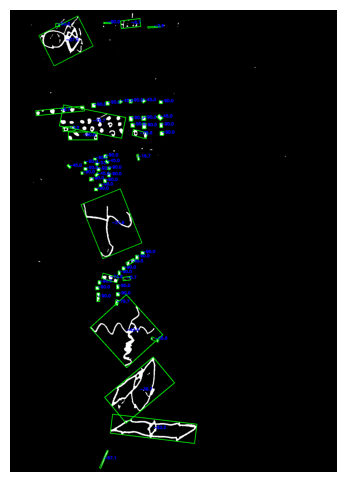

In [31]:
feature_img = cv2.cvtColor(clean, cv2.COLOR_GRAY2BGR)

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area < 50:
        continue

    # rotated rectangle
    rect = cv2.minAreaRect(cnt)

    angle = rect[-1]

    # get rectangle points
    box = cv2.boxPoints(rect)

    box = np.int32(box)

    # draw rotated rectangle
    cv2.drawContours(
        feature_img,
        [box],
        0,
        (0,255,0),
        2
    )

    # center point
    center = (int(rect[0][0]), int(rect[0][1]))

    # write angle
    cv2.putText(
        feature_img,
        f"{angle:.1f}",
        center,
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        2
    )

    print("Rotation Angle =", angle)

# display
plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(feature_img, cv2.COLOR_BGR2RGB))

plt.axis("off")
plt.show()

# upload_img(r"tests\feature.jpg",feature_img)
